# NYC Airbnb Market Analysis – Exploratory Data Analysis

## Objective
This project explores the New York City Airbnb dataset to understand key factors influencing listing prices and demand.

## Key Question
➡️ Where are the best investment opportunities in the NYC Airbnb market?

## Approach
- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Identifying key drivers of price and demand
- Generating business insights

In [4]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_theme(style="whitegrid")

In [5]:
df =  pd.read_csv("../data/AB_NYC_2019.csv")

## First Overview 

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
df.shape # Anzahl Zeilen und Anzahl von Spalten 



(48895, 16)

In [8]:
df.columns # Splt werden wiedergegeben

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [10]:
df.describe() #statistische Zusammenfassung nummerischer Spalten e

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### 🧠 Initial Observations
- Dataset contains Airbnb listings in NYC
- Includes pricing, location, availability, and reviews
- Some columns contain missing values

In [11]:
df.isnull().sum() # returns the number of missing values in the dataset.

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0) # alle fehlenden Wete NaN in der Spalte reviews_per_month werden durch 0 ersetzt. 

### 🔧 Data Cleaning
Missing values in `reviews_per_month` were replaced with 0, assuming no reviews occurred.

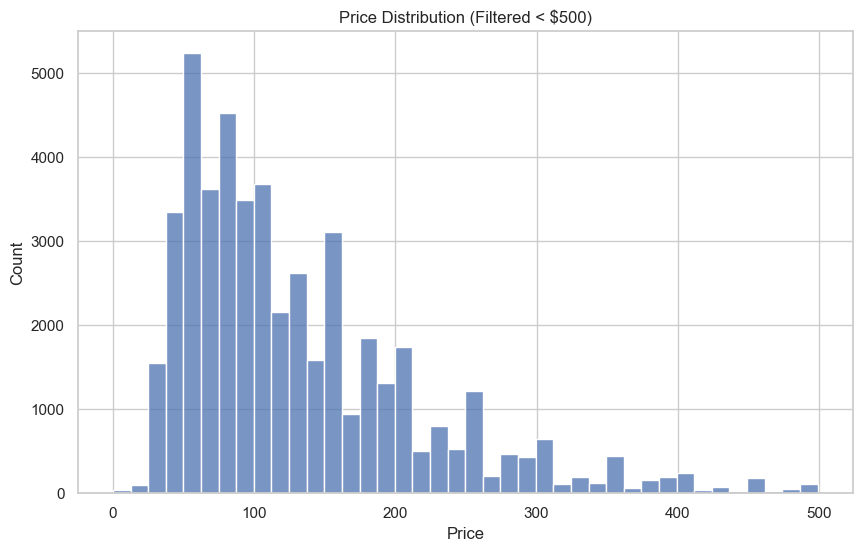

In [13]:
sns.histplot(df[df["price"] < 500]["price"], bins=40)
plt.title("Price Distribution (Filtered < $500)")
plt.xlabel("Price")
plt.show()

### Insight
Prices are heavily right-skewed, with most listings priced below $200 and a few extreme outliers.

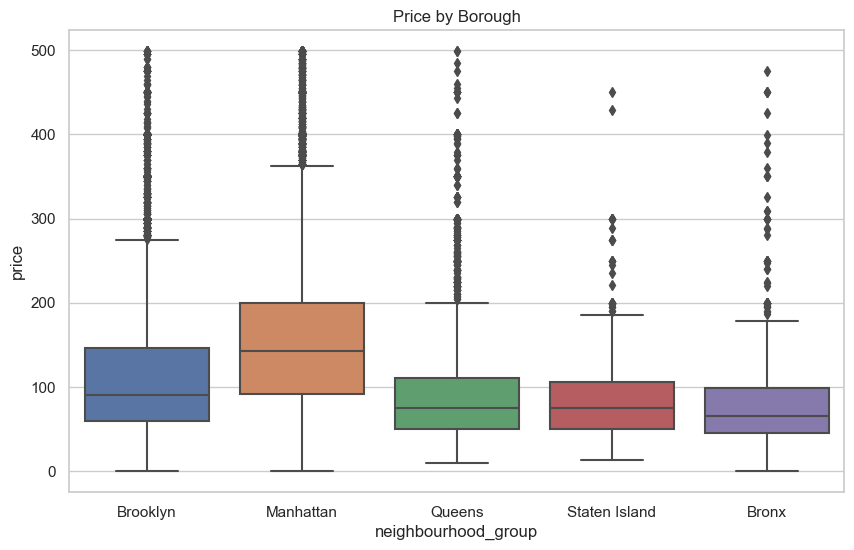

In [14]:
sns.boxplot(data=df[df["price"] < 500], x="neighbourhood_group", y="price")
plt.title("Price by Borough")
plt.show()

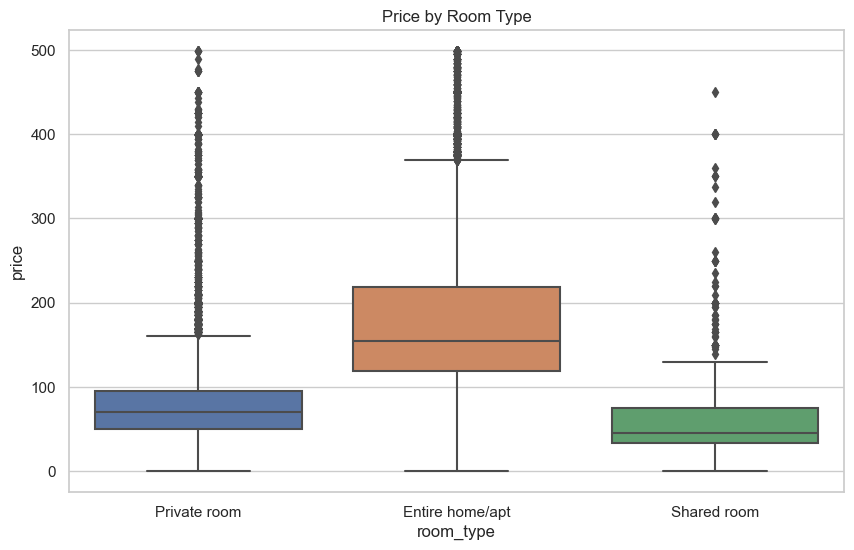

In [15]:
sns.boxplot(data=df[df["price"] < 500], x="room_type", y="price")
plt.title("Price by Room Type")
plt.show()

### Insight
Entire homes are significantly more expensive than private or shared rooms.

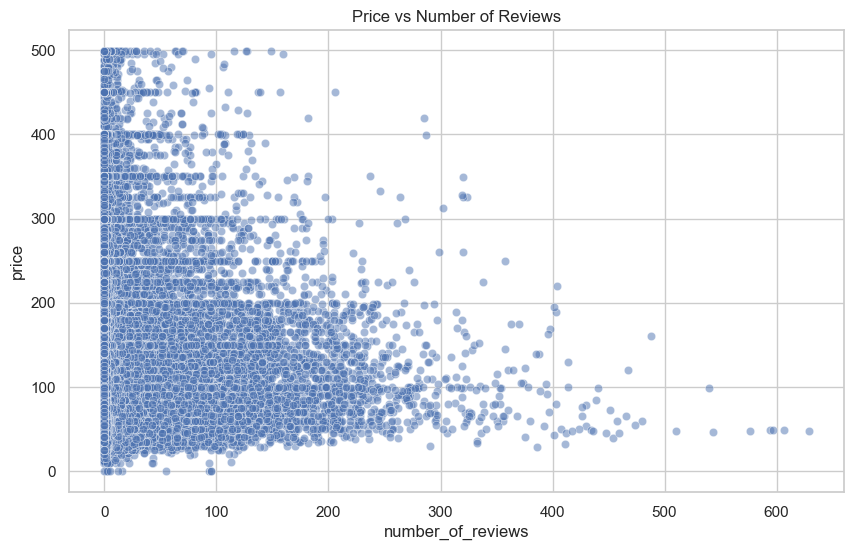

In [16]:
sns.scatterplot(
    data=df[df["price"] < 500],
    x="number_of_reviews",
    y="price",
    alpha=0.5
)
plt.title("Price vs Number of Reviews")
plt.show()

###  Insight
Higher prices do not necessarily lead to more reviews, suggesting demand is not purely price-driven.

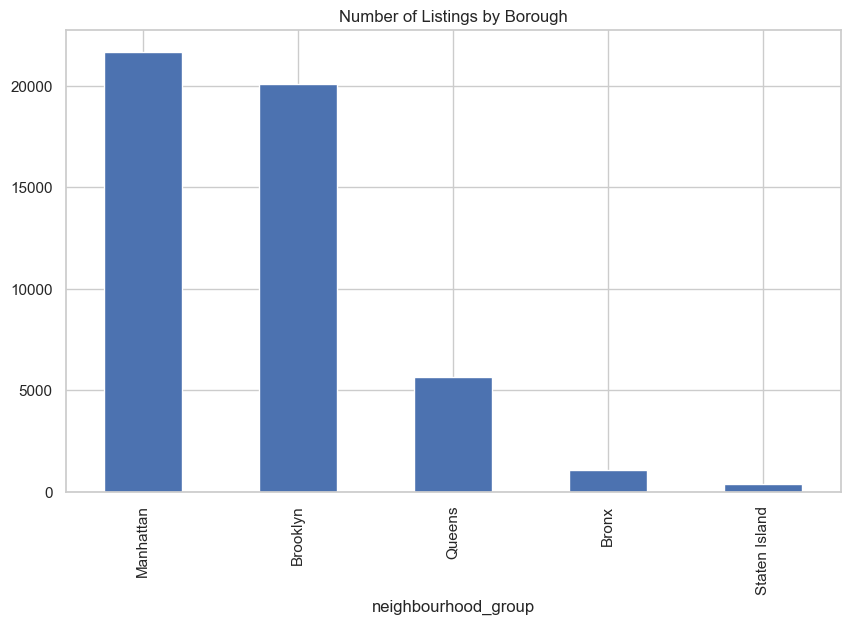

In [17]:
df["neighbourhood_group"].value_counts().plot(kind="bar")
plt.title("Number of Listings by Borough")
plt.show()

### Insight
Some listings require long minimum stays, which may limit demand.

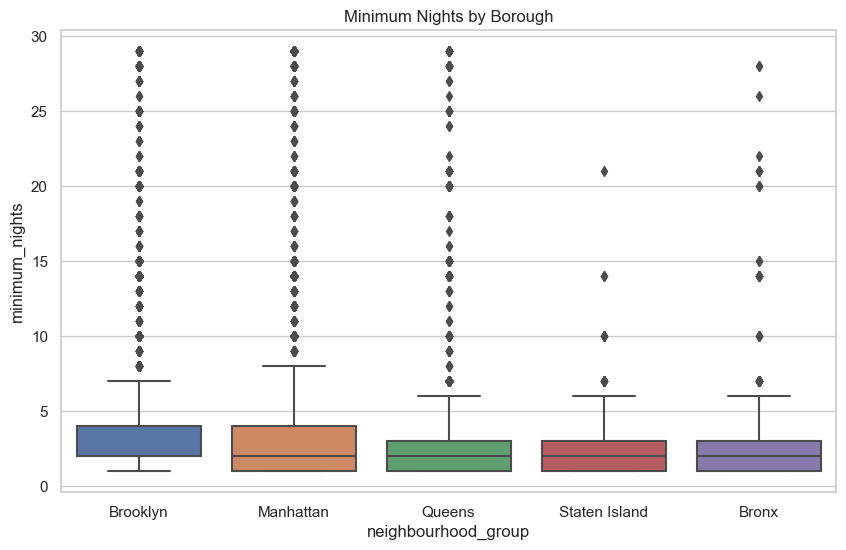

In [18]:
sns.boxplot(data=df[df["minimum_nights"] < 30], x="neighbourhood_group", y="minimum_nights")
plt.title("Minimum Nights by Borough")
plt.show()

### Insight
Some listings require long minimum stays, which may limit demand.

# 📊 Key Insights

- Manhattan has the highest prices but not always the highest demand.
- Brooklyn offers a strong balance between price and listing volume.
- Entire homes generate higher prices but may have lower booking frequency.
- High prices do not guarantee high demand.

# Business Recommendation

➡️ Brooklyn appears to be the most attractive investment area due to a better balance of price and demand compared to Manhattan.

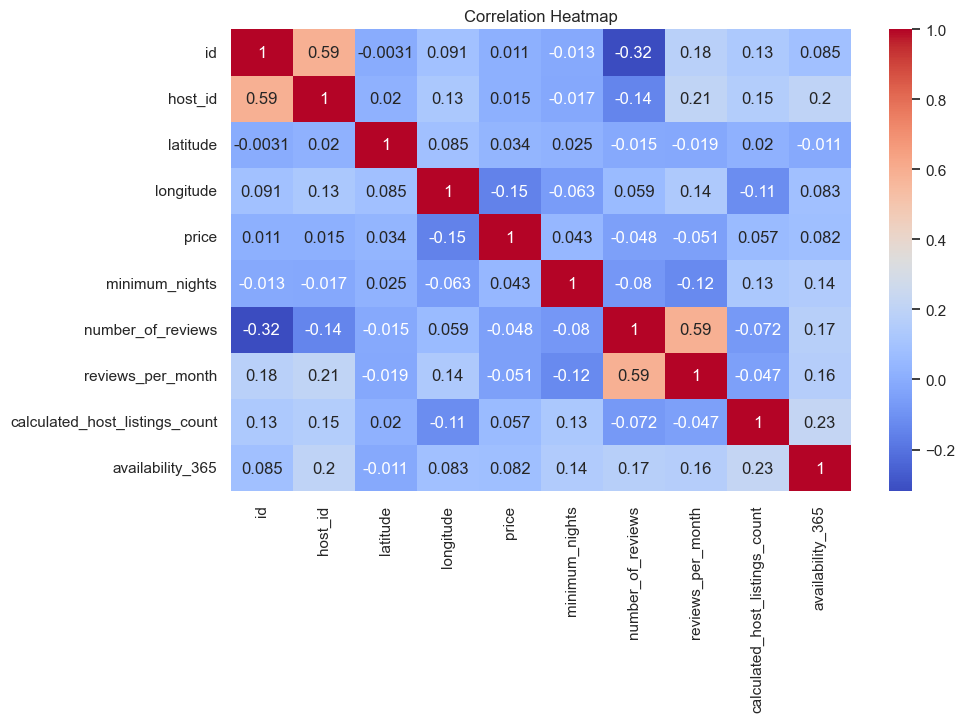

In [19]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
import folium
from folium.plugins import MarkerCluster

# Karte starten (NYC)
map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Marker Cluster (wichtig für Performance)
marker_cluster = MarkerCluster().add_to(map_nyc)

# Beispiel: Top Listings anzeigen
for _, row in df.sample(1000).iterrows():  # sample für Performance
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        color="red" if row["price"] > 150 else "blue",
        fill=True,
        fill_opacity=0.6,
        popup=f"""
        Price: ${row['price']}<br>
        Room: {row['room_type']}<br>
        Reviews: {row['number_of_reviews']}
        """
    ).add_to(marker_cluster)

display(map_nyc)

In [21]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from IPython.display import display


df =  pd.read_csv("../data/AB_NYC_2019.csv")
# -----------------------------
# 1. Stadtteil-Level aggregieren
# -----------------------------
neighborhood_summary = (
    df.groupby(["neighbourhood_group", "neighbourhood"], as_index=False)
      .agg(
          latitude=("latitude", "mean"),
          longitude=("longitude", "mean"),
          listings=("id", "count"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_reviews_per_month=("reviews_per_month", "mean"),
          avg_availability=("availability_365", "mean"),
          avg_minimum_nights=("minimum_nights", "mean")
      )
)

# häufigster Room Type pro Stadtteil
top_room_type = (
    df.groupby(["neighbourhood_group", "neighbourhood", "room_type"])
      .size()
      .reset_index(name="count")
      .sort_values(["neighbourhood_group", "neighbourhood", "count"], ascending=[True, True, False])
      .drop_duplicates(subset=["neighbourhood_group", "neighbourhood"])
      [["neighbourhood_group", "neighbourhood", "room_type"]]
      .rename(columns={"room_type": "top_room_type"})
)

neighborhood_summary = neighborhood_summary.merge(
    top_room_type,
    on=["neighbourhood_group", "neighbourhood"],
    how="left"
)

# Optional: nur Stadtteile mit genügend Listings
neighborhood_summary = neighborhood_summary[neighborhood_summary["listings"] >= 20].copy()

# Werte runden
for col in ["avg_price", "median_price", "avg_reviews", "avg_reviews_per_month",
            "avg_availability", "avg_minimum_nights"]:
    neighborhood_summary[col] = neighborhood_summary[col].round(1)

# -----------------------------
# 2. Farbregel nach Preisklasse
# -----------------------------
def price_color(price):
    if price >= 200:
        return "darkred"
    elif price >= 150:
        return "red"
    elif price >= 100:
        return "orange"
    else:
        return "green"

# -----------------------------
# 3. Karte bauen
# -----------------------------
map_neighborhoods = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=11,
    tiles="CartoDB positron"
)

marker_cluster = MarkerCluster().add_to(map_neighborhoods)

for _, row in neighborhood_summary.iterrows():
    popup_html = f"""
    <div style="width: 260px; font-family: Arial; font-size: 13px;">
        <h4 style="margin-bottom: 8px;">{row['neighbourhood']}</h4>
        <b>Borough:</b> {row['neighbourhood_group']}<br>
        <b>Listings:</b> {int(row['listings'])}<br>
        <b>Avg. Price:</b> ${row['avg_price']}<br>
        <b>Median Price:</b> ${row['median_price']}<br>
        <b>Avg. Reviews:</b> {row['avg_reviews']}<br>
        <b>Reviews / Month:</b> {row['avg_reviews_per_month']}<br>
        <b>Top Room Type:</b> {row['top_room_type']}<br>
        <b>Avg. Availability:</b> {row['avg_availability']} days<br>
        <b>Avg. Minimum Nights:</b> {row['avg_minimum_nights']}<br>
    </div>
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(6, min(row["listings"] / 20, 18)),
        color=price_color(row["avg_price"]),
        fill=True,
        fill_color=price_color(row["avg_price"]),
        fill_opacity=0.7,
        weight=1,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['neighbourhood']} | Avg Price: ${row['avg_price']}"
    ).add_to(marker_cluster)

# -----------------------------
# 4. Legende hinzufügen
# -----------------------------
legend_html = """
<div style="
position: fixed;
bottom: 30px; left: 30px; width: 200px; height: 140px;
background-color: white; z-index:9999; font-size:14px;
border:2px solid grey; border-radius:8px; padding: 10px;">
<b>Avg. Price Level</b><br>
<span style="color:darkred;">●</span> $200+<br>
<span style="color:red;">●</span> $150–199<br>
<span style="color:orange;">●</span> $100–149<br>
<span style="color:green;">●</span> below $100<br><br>
<b>Marker size</b> = number of listings
</div>
"""
map_neighborhoods.get_root().html.add_child(folium.Element(legend_html))

display(map_neighborhoods)


### 🗺️ Neighborhood Airbnb Market Overview

This interactive map provides a neighborhood-level overview of the NYC Airbnb market.

Each marker represents a neighborhood and displays key metrics such as:
- Number of listings
- Average and median price
- Average number of reviews (proxy for demand)
- Most common room type
- Availability and minimum stay requirements

The size of each marker reflects the number of listings, while the color indicates the average price level.

### Key Insight
This visualization highlights that high prices are concentrated in specific areas, particularly in Manhattan. However, several neighborhoods in Brooklyn show a strong balance between price and demand, suggesting attractive investment opportunities.

This map allows users to quickly identify high-performing neighborhoods and compare market dynamics across NYC.

## 📊 Market Overview

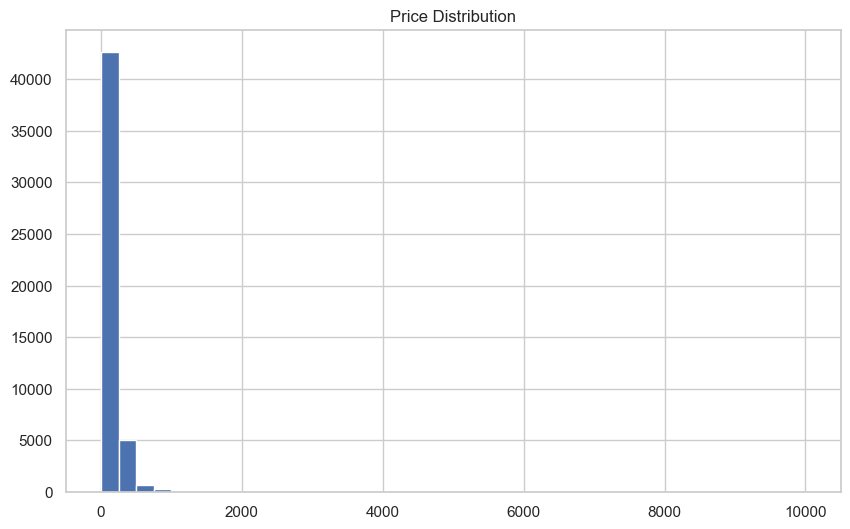

In [22]:
df["price"].hist(bins=40)
plt.title("Price Distribution")
plt.show()

## 💰 What drives Airbnb prices?

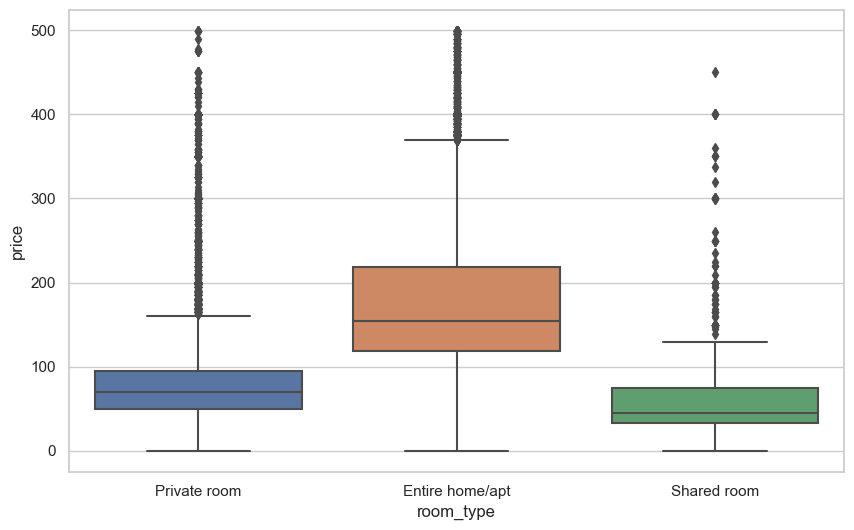

In [23]:
sns.boxplot(data=df[df["price"] < 500], x="room_type", y="price")
plt.show()

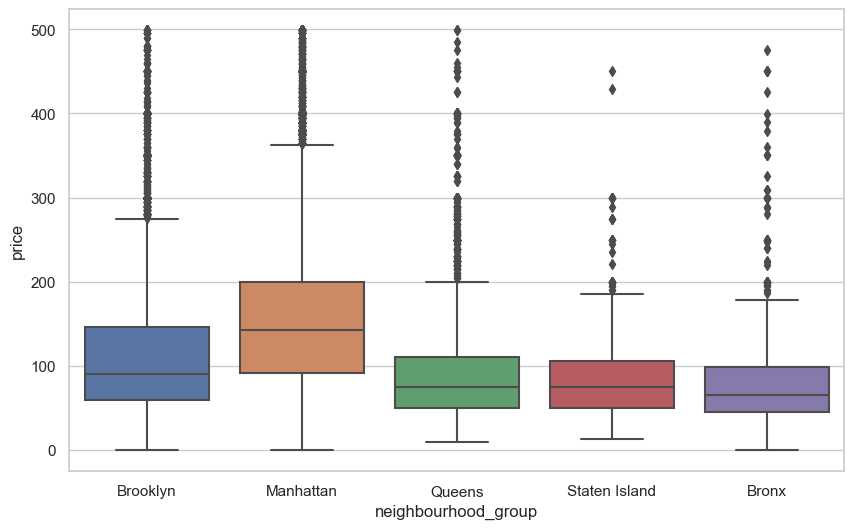

In [24]:
sns.boxplot(data=df[df["price"] < 500], x="neighbourhood_group", y="price")
plt.show()

## 📈 Demand Indicators

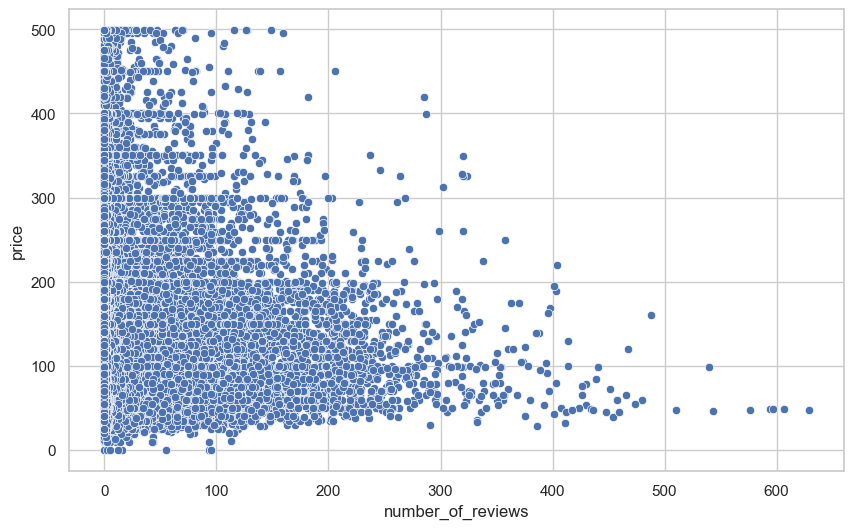

In [26]:
sns.scatterplot(
    data=df[df["price"] < 500],
    x="number_of_reviews",
    y="price"
)
plt.show()

In [27]:
df.to_csv("../data/clean_airbnb.csv", index=False)